# 0. Project about Image classification

* Im `Daniel_Tuana` and I prefer CIFAR dataset to do my first own project.
* This is the built -in datasets https://docs.pytorch.org/vision/stable/datasets.html **read here to get more useful information**.


# 1. Prepare datasets (the most important) and Import necessary libraries 

In [1]:
import torch # base place where everything starts 
from torch import nn # Which will build the brain's model


import torchvision # Processing data (preparing and transform processing)

from torchvision import datasets # The place to get data

from torchvision import transforms # Turn to Tensor

import matplotlib.pyplot as plt # Visualize model'results what I do almost

from torchvision.transforms import ToTensor

print(torch.__version__)
print(torchvision.__version__)


2.13.0+cu130
0.28.0+cu130


## 1.1 Preparing data CIFAR (`respectful and classic`)

In [2]:
# Let start the transform pipline first.

# transform which I'm using for discover

normal_transform = transforms.Compose([
	## Optional using transform Illustration of transforms
	transforms.ToTensor()
])


# transforms which I'm actually using for model
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])



## 1.2 Downloading data 

In [3]:
train_data = datasets.CIFAR10(
	root="data", 
	train=True, 
	download=True, 
	transform=normal_transform, 
	target_transform=None
)
test_data = datasets.CIFAR10(
	root='data',
	train=False,
	download=True,
	transform=test_transform,
	target_transform=None
	
)


### 1.2.1 Discover the data

In [4]:
# Check lenght of the data
len(train_data), len(test_data)

(50000, 10000)

In [5]:
# Take a look with the data
img, label = train_data[0]
img, label

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [6]:
class_names, class_to_idx = train_data.classes, train_data.class_to_idx
class_names, class_to_idx

(['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'],
 {'airplane': 0,
  'automobile': 1,
  'bird': 2,
  'cat': 3,
  'deer': 4,
  'dog': 5,
  'frog': 6,
  'horse': 7,
  'ship': 8,
  'truck': 9})

In [7]:
img.shape

torch.Size([3, 32, 32])

### 1.2.2 Visualize some sample

Image shape: torch.Size([3, 32, 32])


Text(0.5, 1.0, 'class: frog')

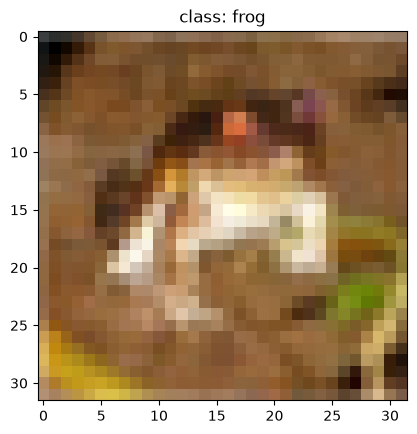

In [8]:
print(f'Image shape: {img.shape}')
plt.imshow(img.permute(1,2,0))
plt.title(f'class: {class_names[label]}')

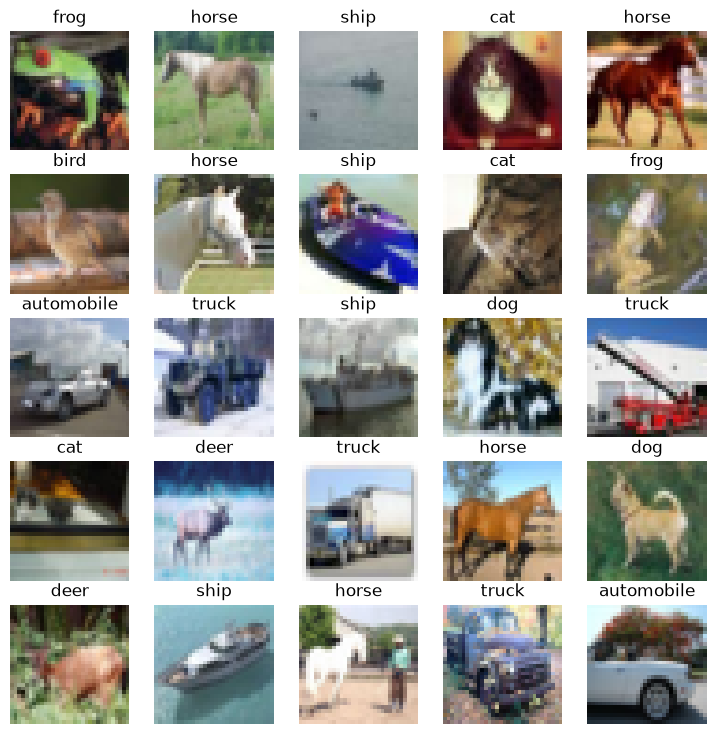

In [9]:
# plot random sample
torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 5,5

for i in range(1, rows * cols +1):
	random_idx = torch.randint(0, len(train_data), size=[1]).item()
	img, label = train_data[random_idx]
	fig.add_subplot(rows,cols, i)
	plt.imshow(img.permute(1,2,0), cmap='gray')
	plt.title(class_names[label])
	plt.axis(False)

### 1.2.3 More fun with make a func to show a random image

In [10]:

import random
from typing import List
def display_random_img (dataset: torch.utils.data.Dataset,
						class_names: List[str] = None,
						display_shape: bool = True,
						number_of_sample: int=10,
						seed: int = None):
	pass
	if number_of_sample > 10:
		number_of_sample = 10
		display_shape = False
		print(f'For display Purpose, do not set n higher than {number_of_sample}')

	if seed: 
		torch.manual_seed(seed)
	random_img_idx = random.sample(range(len(dataset)), number_of_sample)

	plt.figure(figsize=(16,8))

	for i, sample_idx in enumerate(random_img_idx):
		img, label = dataset[sample_idx]

		plt.subplot(1, number_of_sample, i + 1)
		plt.imshow(img.permute(1,2,0))
		plt.axis(False)
		if class_names:
			title = f'Class: {class_names[label]}\n'
			if display_shape:	
				title = title + f'\nshape:\n {img.permute(1,2,0).shape}'
		plt.title(title, fontsize = 8)


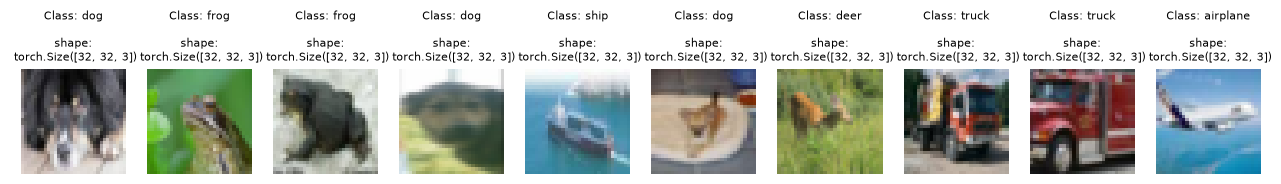

In [11]:
display_random_img(dataset=train_data, class_names=class_names, seed=None)

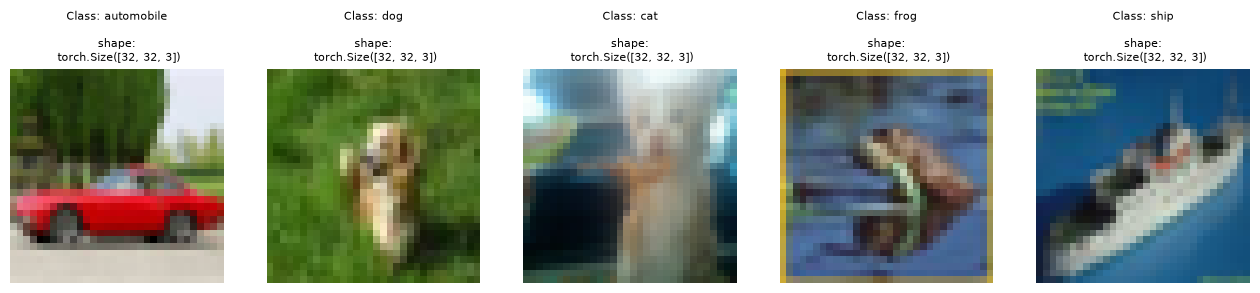

In [12]:
display_random_img(dataset=train_data, class_names=class_names, number_of_sample=5, seed=None)

In [13]:
print(type(train_data.transform))

<class 'torchvision.transforms.transforms.Compose'>


### 1.3 Final preparing process

In [14]:
#At the step 1.2 my train data just using a normal transform, so I have to turn it into a train transform
train_data.transform = train_transform

# Turn data into dataloader
from torch.utils.data import DataLoader
import os
# Batch size: I do not handle all img one time, so it makes performance 's model went wrong. 
# The right way: I have to separate into a bunch of img (batch) normally is 32 img in a bunch.
BATCH_SIZE = 32
NUM_WORKER = os.cpu_count()

train_dataloader = DataLoader(dataset=train_data, 
							batch_size= BATCH_SIZE, 
							shuffle=True, 
							num_workers=NUM_WORKER )

test_dataloader = DataLoader(dataset=test_data, 
							batch_size=BATCH_SIZE, 
							shuffle=False, 
							num_workers=NUM_WORKER)

# 2. Build a model for detect a picture

## 2.1 Build the brain for model using torch.nn.Module

In [26]:
class myOwnVGG(nn.Module):
	def __init__(self,input_shape: int, hidden_units: int, output_shape: int) -> None:
		super().__init__()

		self.conv_block_1 = nn.Sequential(
			nn.Conv2d(in_channels=input_shape,out_channels=hidden_units, kernel_size=3,padding=1 ,stride=1),
			nn.ReLU(),
			nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2, stride=2)
		)
		self.conv_block_2 = nn.Sequential(
			nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units, kernel_size=3,padding=1 ,stride=1),
			nn.ReLU(),
			nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2, stride=2)
		)
		self.conv_block_3 = nn.Sequential(
			nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units, kernel_size=3,padding=1 ,stride=1),
			nn.ReLU(),
			nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2, stride=2)
		)
		self.conv_block_4 = nn.Sequential(
			nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units, kernel_size=3,padding=1 ,stride=1),
			nn.ReLU(),
			nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1,stride=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2, stride=2)
		)

		self.classifier = nn.Sequential(
			nn.Flatten(),
			nn.Linear(in_features=hidden_units*2*2, out_features=output_shape)
		)

	def forward(self,x):
		x = self.conv_block_1(x)
		#print(f'X shape: {x.shape}')
		x = self.conv_block_2(x)
		#print(f'X shape: {x.shape}')
		x = self.conv_block_3(x)
		#print(f'X shape: {x.shape}')
		x = self.conv_block_4(x)
		# print(f'X shape: {x.shape}')
		x = self.classifier(x)
		return x
		
		
		


In [27]:
image_batch, label_batch = next(iter(train_dataloader))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 32, 32]), torch.Size([32]))

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [29]:
torch.manual_seed(42)

model = myOwnVGG(input_shape=3, hidden_units=32, output_shape=len(class_names)).to(device)
model

myOwnVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_4): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), pa

In [30]:
model(image_batch.to(device))

tensor([[-0.0622,  0.0614, -0.0188,  0.0415,  0.0761, -0.0686, -0.0104,  0.0236,
          0.0749,  0.0676],
        [-0.0621,  0.0609, -0.0190,  0.0415,  0.0761, -0.0686, -0.0108,  0.0234,
          0.0752,  0.0682],
        [-0.0626,  0.0614, -0.0189,  0.0414,  0.0758, -0.0685, -0.0108,  0.0238,
          0.0750,  0.0676],
        [-0.0620,  0.0613, -0.0190,  0.0417,  0.0761, -0.0685, -0.0111,  0.0239,
          0.0755,  0.0679],
        [-0.0621,  0.0614, -0.0190,  0.0416,  0.0753, -0.0687, -0.0108,  0.0237,
          0.0751,  0.0674],
        [-0.0619,  0.0614, -0.0186,  0.0414,  0.0760, -0.0691, -0.0105,  0.0235,
          0.0750,  0.0678],
        [-0.0624,  0.0610, -0.0190,  0.0417,  0.0757, -0.0686, -0.0113,  0.0240,
          0.0756,  0.0679],
        [-0.0624,  0.0614, -0.0192,  0.0416,  0.0759, -0.0688, -0.0113,  0.0244,
          0.0751,  0.0684],
        [-0.0624,  0.0615, -0.0191,  0.0419,  0.0762, -0.0687, -0.0110,  0.0237,
          0.0752,  0.0677],
        [-0.0623,  

In [31]:
def train_step(model: torch.nn.Module, 
				dataloader: torch.utils.data.DataLoader, 
				loss_fn: torch.nn.Module,
				optimizer: torch.optim.Optimizer,
				device=device):

	model.train()
	train_loss, train_acc = 0,0

	for batch , (X,y) in enumerate(dataloader):
		X,y = X.to(device), y.to(device)

		y_pred = model(X)

		loss = loss_fn(y_pred,y)
		train_loss += loss.item()

		optimizer.zero_grad()

		loss.backward()

		optimizer.step()

		y_pred_class = torch.argmax(y_pred, dim=1)

		train_acc += (y_pred_class == y).sum().item() / len(y_pred)

	
	train_loss = train_loss / len(dataloader)
	train_acc = train_acc / len(dataloader)
	return train_loss, train_acc
		


In [32]:
def test_step(model: torch.nn.Module,
				dataloader: torch.utils.data.DataLoader,
				loss_fn : torch.nn.Module,
				device = device):
	model.eval()
	test_loss, test_acc = 0 ,0

	with torch.inference_mode():
		for batch, (X,y) in enumerate(dataloader):
			X,y = X.to(device), y.to(device)

			test_logits = model(X)
			loss = loss_fn(test_logits,y)
			test_loss += loss.item()

			test_pred_labels = test_logits.argmax(dim=1)

			test_acc += ((test_pred_labels==y).sum().item()/ len(y))
	
	test_loss = test_loss / len(dataloader)
	test_acc = test_acc /len(dataloader)
	return test_loss,test_acc



## 2.1 Set up loss_fn and optimizer

In [33]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)


In [34]:
def train (model: torch.nn.Module,
            train_dataloader: torch.utils.data.DataLoader,
            test_dataloader: torch.utils.data.DataLoader,
            optimizer: torch.optim.Optimizer,
            loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
            epochs: int = 5,
            device=device):
	results = {"train_loss": [],
			"train_acc": [],
			"test_loss": [],
			"test_acc": []} 
	for epoch in range(epochs):
		train_loss, train_acc = train_step(model=model, dataloader=train_dataloader, loss_fn=loss_fn,optimizer=optimizer, device=device)

		test_loss, test_acc = test_step(model=model, dataloader=test_dataloader, loss_fn=loss_fn, device=device)

		print(f'Epoch: {epoch} | Train loss:  {train_loss:.4f} | Train accuracy: {train_acc * 100:.2f}% | Test loss: {test_loss:.4f} | Test accuracy: {test_acc*100:.2f}%')


		results["train_loss"].append(train_loss)
		results["train_acc"].append(train_acc)
		results["test_loss"].append(test_loss)
		results["test_acc"].append(test_acc)

	return results


### 2.3 Training

In [35]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 6

model_result = train(model=model,
					train_dataloader=train_dataloader, 
					test_dataloader=test_dataloader,
					optimizer=optimizer, 
					loss_fn=loss_fn, epochs=EPOCHS)


Epoch: 0 | Train loss:  1.7676 | Train accuracy: 33.35% | Test loss: 1.4908 | Test accuracy: 45.54%
Epoch: 1 | Train loss:  1.3489 | Train accuracy: 50.21% | Test loss: 1.2001 | Test accuracy: 56.11%
Epoch: 2 | Train loss:  1.1401 | Train accuracy: 58.45% | Test loss: 1.1103 | Test accuracy: 59.75%
Epoch: 3 | Train loss:  1.0130 | Train accuracy: 63.77% | Test loss: 1.0407 | Test accuracy: 62.91%
Epoch: 4 | Train loss:  0.9330 | Train accuracy: 66.86% | Test loss: 0.9545 | Test accuracy: 66.88%
Epoch: 5 | Train loss:  0.8745 | Train accuracy: 69.20% | Test loss: 0.8244 | Test accuracy: 71.66%


In [36]:
def make_predictions(
    model: torch.nn.Module,
    data: list,
    device: torch.device = device
):
    pred_probs = []

    model.eval()

    with torch.inference_mode():

        for sample in data:

            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = model(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

In [43]:
import random

# random.seed(42)

test_samples=[]
test_labels= []

for sample, label in random.sample(list(test_data), k =9):
    test_samples.append(sample)
    test_labels.append(label)

test_samples[0].shape

torch.Size([3, 32, 32])

In [44]:
pred_probs = make_predictions(model=model, data=test_samples)

pred_probs[:2]

tensor([[0.0183, 0.0006, 0.0570, 0.0115, 0.3279, 0.0216, 0.0031, 0.5565, 0.0008,
         0.0028],
        [0.0076, 0.0072, 0.1544, 0.1351, 0.0942, 0.3857, 0.0730, 0.0996, 0.0091,
         0.0341]])

In [45]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([7, 5, 0, 5, 8, 3, 3, 1, 6])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6243074..1.0112408].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9735969..2.0858443].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.7560488].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.9654387].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.894213..1.6916536].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737

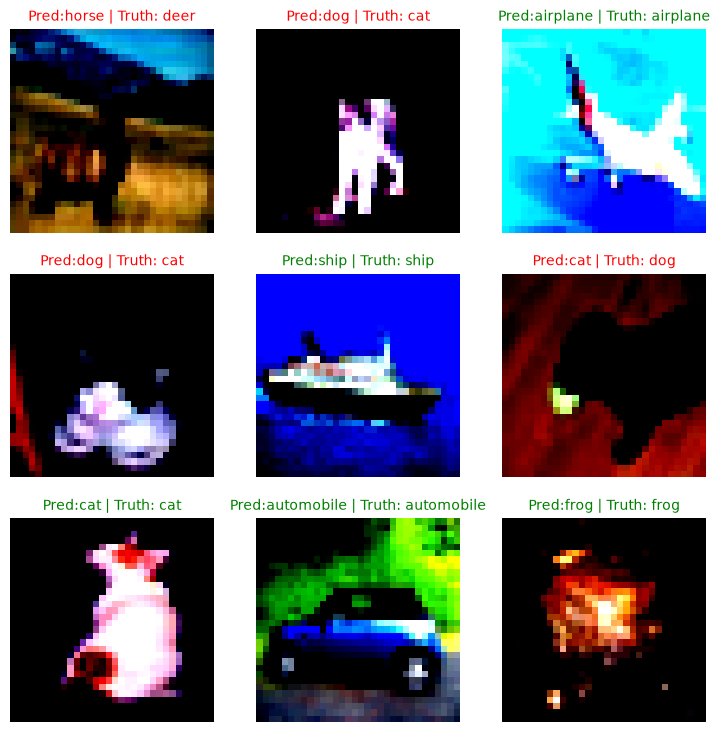

In [46]:
plt.figure(figsize=(9,9))

nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(sample.permute(1,2,0) )

    pred_label = class_names[pred_classes[i]]

    truth_label = class_names[test_labels[i]]

    title_text  = f'Pred:{pred_label} | Truth: {truth_label}'

    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c='r')
    plt.axis(False)